# Refracción atmosférica: desarrollo ampliado de la actividad

**Curso:** Introducción a la Astronomía Práctica  
**Tema:** Efecto de la atmósfera en la posición y forma aparente de objetos celestes

Este cuaderno desarrolla de forma más extensa la actividad de la carpeta **RefraccionAtmosferica**.  
Además de los cálculos numéricos, se incluye una discusión física más detallada, interpretación observacional y visualizaciones para ver de manera aproximada el **achatamiento del disco solar/lunar** cuando el astro está cerca del horizonte.

La meta es conectar tres niveles:  
1. el modelo matemático de refracción,  
2. la estimación cuantitativa en datos tipo observación,  
3. la apariencia real del disco en el cielo.


## 1. Contexto físico

La atmósfera terrestre es un medio estratificado: su densidad, presión y temperatura cambian con la altura. En términos ópticos, esto implica que el índice de refracción del aire no es constante. Por esa razón, la luz de un astro no sigue una recta perfecta al atravesar la atmósfera, sino una trayectoria curva que se desvía gradualmente hacia las capas más densas.

Consecuencias observacionales principales:

- Un objeto cercano al horizonte se observa **más alto** que su posición geométrica real.
- En objetos extensos (Sol/Luna), el borde inferior atraviesa una porción atmosférica más densa que el borde superior y sufre mayor desviación: aparece un **achatamiento vertical**.
- El amanecer ocurre unos minutos antes y el atardecer unos minutos después respecto al caso sin atmósfera.

En astronomía de posición, estos efectos pueden introducir errores de varios minutos de arco si no se aplican correcciones.


## 2. Objetivos

1. Cuantificar cómo cambia la razón de aspecto del disco $W/h_v$ con la altura angular $h$.
2. Comparar alturas aparentes y geométricas para estimar el corrimiento por refracción.
3. Evaluar cómo cambian los resultados al modificar condiciones locales de presión y temperatura.
4. Visualizar gráficamente la deformación para que el achatamiento sea evidente de forma cualitativa y cuantitativa.
5. Discutir implicaciones para observación, astrometría y reducción de datos.


## 3. Ecuación de trabajo

Usaremos la aproximación empírica indicada en la guía para la refracción atmosférica en minutos de arco:

$$R\,[\text{arcmin}] = \cot \left( h[^\circ] + \frac{7.31}{h[^\circ] + 4.4} \right) \left( \frac{P}{101\,\text{kPa}} \right) \left( \frac{273}{273 + T} \right)$$

donde:

- $h$: altura angular en grados,
- $P$: presión atmosférica en kPa,
- $T$: temperatura en $^\circ\mathrm{C}$.

La conversión a grados se hace con:

$$
R_{\text{deg}} = \frac{R_{\text{arcmin}}}{60}
$$

Por tanto, una estimación de la altura aparente es:

$$
h_{\text{aparente}} \approx h_{\text{geom}} + R_{\text{deg}}
$$


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('classic')


def refraccion_arcmin(h_deg, P_kpa=84.0, T_c=18.0):
    """Aproximación de refracción atmosférica (arcmin)."""
    h = np.asarray(h_deg, dtype=float)
    arg_deg = h + 7.31/(h + 4.4)
    R = 1/np.tan(np.deg2rad(arg_deg))
    R *= (P_kpa/101.0) * (273.0/(273.0 + T_c))
    return R


## 4. Experimento 0: deformación del disco (datos realistas)

Se simula una secuencia fotográfica de puesta del Sol con filtro solar. Los diámetros en píxeles son coherentes con una misma distancia focal: el diámetro horizontal cambia poco, mientras el vertical aumenta con la altura al disminuir la refracción diferencial.

**Condiciones de observación supuestas (realistas):**

- Ciudad: Medellín ($\sim 1500\,\mathrm{m}$ s.n.m.)
- Temperatura ambiente: $18\,^\circ\mathrm{C}$
- Presión local: $84\,\mathrm{kPa}$
- Intervalo temporal entre imágenes: 4 a 6 minutos

En esta parte, el indicador clave es la razón de aspecto $W/h_v$. Si $W/h_v>1$, el disco está comprimido en vertical.


In [8]:
# Tabla 0: mediciones del disco en pixeles
altura_deg = np.array([1.2, 2.5, 4.0, 5.8, 7.6, 9.5, 12.0, 15.0, 18.5])
ancho_px   = np.array([1888, 1887, 1889, 1886, 1888, 1887, 1888, 1887, 1888])
alto_px    = np.array([1548, 1623, 1698, 1750, 1789, 1814, 1846, 1868, 1881])

ratio = ancho_px / alto_px

tabla0 = pd.DataFrame({
    'Hora local': ['17:58','18:03','18:08','18:13','18:18','18:24','18:30','18:37','18:45'],
    'Altura h (deg)': altura_deg,
    'Ancho W (px)': ancho_px,
    'Alto hv (px)': alto_px,
    'W/hv': np.round(ratio, 3)
})

tabla0


,Hora local,Altura h (deg),Ancho W (px),Alto hv (px),W/hv
0,17:58,1.2,1888,1548,1.220
1,18:03,2.5,1887,1623,1.163
2,18:08,4.0,1889,1698,1.112
3,18:13,5.8,1886,1750,1.078
4,18:18,7.6,1888,1789,1.055
5,18:24,9.5,1887,1814,1.040
6,18:30,12.0,1888,1846,1.023
7,18:37,15.0,1887,1868,1.010
8,18:45,18.5,1888,1881,1.004


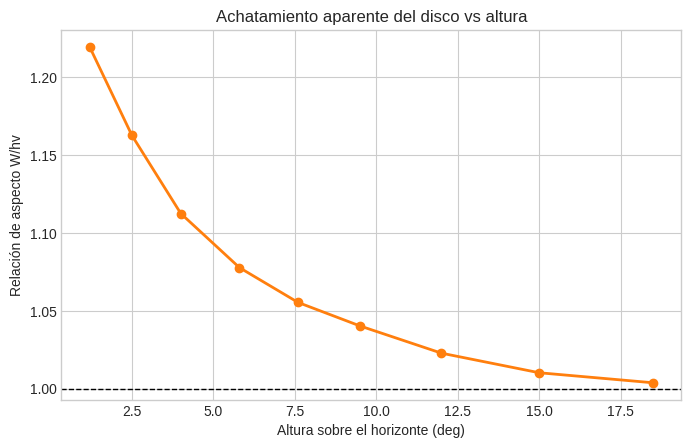

In [9]:
fig, ax = plt.subplots(figsize=(8,4.8))
ax.plot(altura_deg, ratio, 'o-', color='tab:orange', lw=2)
ax.axhline(1.0, color='k', ls='--', lw=1)
ax.set_xlabel('Altura sobre el horizonte (deg)')
ax.set_ylabel('Relación de aspecto W/hv')
ax.set_title('Achatamiento aparente del disco vs altura')
plt.show()


### Interpretación del Experimento 0

- Cerca del horizonte ($h\approx 1$ a $3^\circ$), la razón $W/h_v$ es claramente mayor que 1; esto confirma compresión vertical apreciable.
- Al aumentar la altura, $W/h_v	o 1$, lo que indica recuperación progresiva de una forma casi circular.
- En esta serie, la deformación se vuelve poco perceptible para $h\gtrsim 12^\circ$, donde la razón se acerca a valores de 1.02 o menores.


## 4.1 Visualización geométrica del achatamiento

Para ver el efecto de forma directa, representamos discos normalizados donde el ancho horizontal se fija en 1 y la altura vertical se ajusta según la razón observada $W/h_v$.

Si definimos $r=W/h_v$, entonces la altura relativa del disco es:

$$

rac{h_v}{W}=
rac{1}{r}.
$$

Así, valores grandes de $r$ producen elipses más achatadas en vertical.


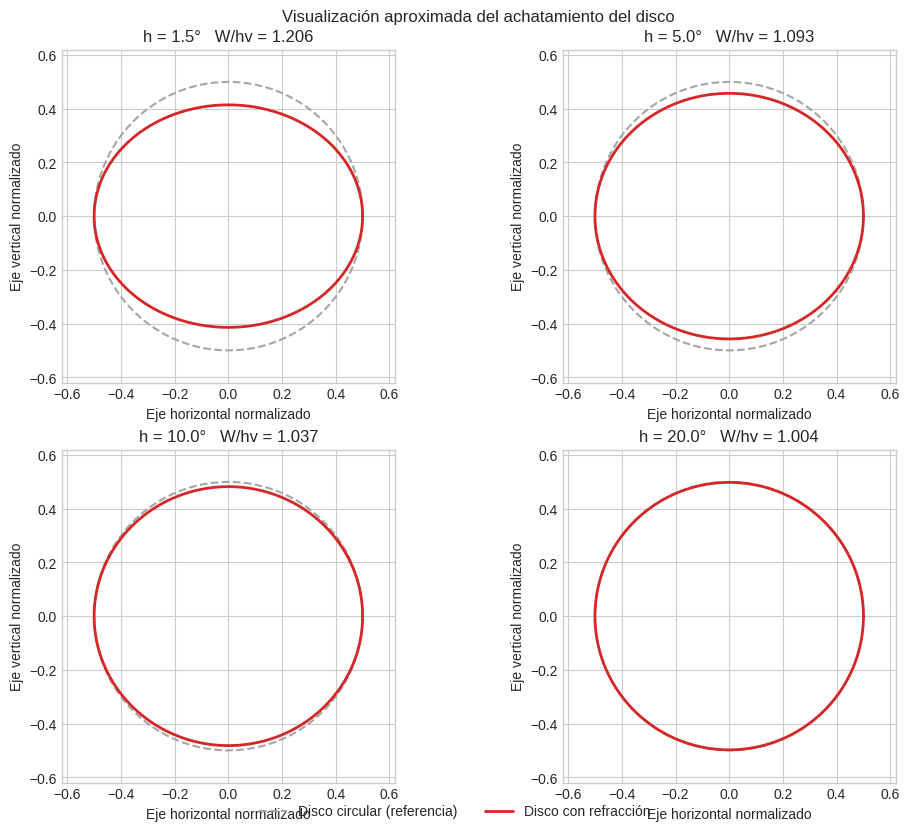

In [10]:
# Elipses aproximadas del disco para distintas alturas
alturas_demo = np.array([1.5, 5.0, 10.0, 20.0])
ratio_demo = np.interp(alturas_demo, altura_deg, ratio)

t = np.linspace(0, 2*np.pi, 500)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for ax, h_i, r_i in zip(axes.ravel(), alturas_demo, ratio_demo):
    a = 0.5                 # semieje horizontal fijo
    b = 0.5 / r_i           # semieje vertical a partir de W/hv

    x = a*np.cos(t)
    y = b*np.sin(t)

    x_ref = a*np.cos(t)
    y_ref = a*np.sin(t)

    ax.plot(x_ref, y_ref, '--', color='0.65', lw=1.5, label='Disco circular (referencia)')
    ax.plot(x, y, color='tab:red', lw=2, label='Disco con refracción')
    ax.set_title(f'h = {h_i:.1f}°   W/hv = {r_i:.3f}')
    ax.set_aspect('equal')
    ax.set_xlim(-0.62, 0.62)
    ax.set_ylim(-0.62, 0.62)
    ax.set_xlabel('Eje horizontal normalizado')
    ax.set_ylabel('Eje vertical normalizado')

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, frameon=False)
fig.suptitle('Visualización aproximada del achatamiento del disco', y=1.02)
plt.show()


### Interpretación visual

En los paneles anteriores se aprecia que cerca del horizonte la elipse comprimida difiere claramente del círculo de referencia. Al subir en altura, la diferencia disminuye y la figura tiende a circularse.

Esta visualización no pretende ser un trazado óptico exacto capa por capa, sino una representación aproximada y útil del efecto observado en fotografía astronómica.


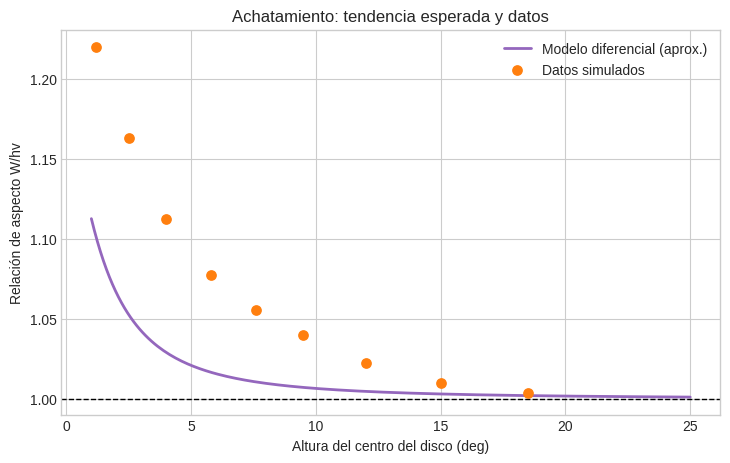

In [11]:
# Estimación simple del achatamiento a partir de refracción diferencial (borde inferior vs superior)
diametro_angular = 0.53  # deg, valor típico Sol/Luna
h_centro = np.linspace(1.0, 25.0, 200)

h_inf = np.clip(h_centro - diametro_angular/2, 0.1, None)
h_sup = h_centro + diametro_angular/2

R_inf = refraccion_arcmin(h_inf, P_kpa=84.0, T_c=18.0)/60.0
R_sup = refraccion_arcmin(h_sup, P_kpa=84.0, T_c=18.0)/60.0

diam_vertical_ap = diametro_angular + (R_sup - R_inf)
ratio_modelo = diametro_angular / diam_vertical_ap

fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.plot(h_centro, ratio_modelo, color='tab:purple', lw=2, label='Modelo diferencial (aprox.)')
ax.scatter(altura_deg, ratio, color='tab:orange', s=45, zorder=3, label='Datos simulados')
ax.axhline(1.0, color='k', ls='--', lw=1)
ax.set_xlabel('Altura del centro del disco (deg)')
ax.set_ylabel('Relación de aspecto W/hv')
ax.set_title('Achatamiento: tendencia esperada y datos')
ax.legend()
plt.show()


## 5. Experimento 1: alturas aparentes vs reales

Se toman tres estrellas brillantes visibles a baja altura. Se registra su altura geométrica (sin atmósfera) y su altura aparente (con atmósfera), como se haría en Stellarium al alternar la opción de atmósfera.

Para consistencia con Medellín, se usa $P=84\,\mathrm{kPa}$ y $T=18^\circ\mathrm{C}$ al evaluar la ecuación.


In [12]:
# Tabla 1: estrellas a baja altura
estrellas = ['Fomalhaut', 'Sirius', 'Aldebarán']
a_real = np.array([5.0, 15.0, 25.0])  # altura geométrica (sin atmósfera)

R_arcmin = refraccion_arcmin(a_real, P_kpa=84.0, T_c=18.0)
R_deg = R_arcmin / 60.0
a_ap = a_real + R_deg

tabla1 = pd.DataFrame({
    'Estrella': estrellas,
    'Altura real (deg)': np.round(a_real, 3),
    'Altura aparente (deg)': np.round(a_ap, 3),
    'Delta a (deg)': np.round(a_ap - a_real, 3),
    'Refracción R (arcmin)': np.round(R_arcmin, 2)
})

tabla1


,Estrella,Altura real (deg),Altura aparente (deg),Delta a (deg),Refracción R (arcmin)
0,Fomalhaut,5.0,5.129,0.129,7.71
1,Sirius,15.0,15.047,0.047,2.84
2,Aldebarán,25.0,25.028,0.028,1.65


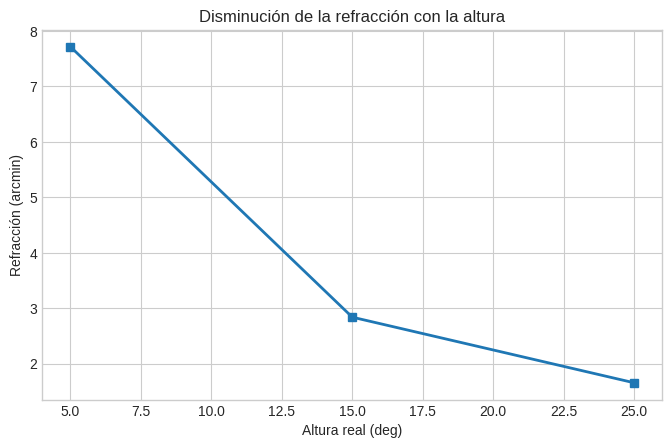

In [13]:
fig, ax = plt.subplots(figsize=(8,4.8))
ax.plot(a_real, R_arcmin, 's-', color='tab:blue', lw=2)
ax.set_xlabel('Altura real (deg)')
ax.set_ylabel('Refracción (arcmin)')
ax.set_title('Disminución de la refracción con la altura')
plt.show()


### Interpretación del Experimento 1

- La refracción calculada es mayor a baja altura y cae rápidamente al aumentar $h$.
- Una estrella a $5^\circ$ puede desplazarse varios minutos de arco; a $25^\circ$ el corrimiento es bastante menor.
- Este comportamiento concuerda con la física del problema: rayos cercanos al horizonte recorren una mayor masa de aire efectiva.


## 6. Comparación Barranquilla vs Medellín (pregunta 2)

Para una misma estrella baja en el horizonte, comparamos el modelo en dos condiciones realistas:

* **Barranquilla (casi nivel del mar):** $P \approx 101$ kPa, $T \approx 30$ °C
* **Medellín (montaña):** $P \approx 84$ kPa, $T \approx 18$ °C


In [14]:
h_test = np.array([5.0, 10.0, 15.0])
R_baq = refraccion_arcmin(h_test, P_kpa=101.0, T_c=30.0)
R_med = refraccion_arcmin(h_test, P_kpa=84.0, T_c=18.0)

comparacion = pd.DataFrame({
    'h (deg)': h_test,
    'R Barranquilla (arcmin)': np.round(R_baq, 2),
    'R Medellín (arcmin)': np.round(R_med, 2),
    'Diferencia BAQ-MDE (arcmin)': np.round(R_baq - R_med, 2)
})

comparacion


,h (deg),R Barranquilla (arcmin),R Medellín (arcmin),Diferencia BAQ-MDE (arcmin)
0,5.0,8.90,7.71,1.19
1,10.0,4.86,4.21,0.65
2,15.0,3.28,2.84,0.44


Se observa que, para la misma altura, Barranquilla presenta refracción algo mayor por su presión más alta. Por tanto, **no medirían exactamente la misma altura aparente**.


## 7. Respuestas a las preguntas de análisis y conclusiones

### 7.1 Tendencia de $W/h_v$ vs altura
La tendencia es decreciente hacia 1. Esto indica que la deformación vertical es máxima junto al horizonte y disminuye con la altura. En esta serie, alrededor de $12^\circ$ a $15^\circ$ el achatamiento ya es visualmente pequeño.

### 7.2 ¿Misma altura aparente en Barranquilla y Medellín?
No. De acuerdo con la ecuación, $R$ escala aproximadamente con $P$ y también depende de $T$. Como Barranquilla tiene mayor presión media, la refracción es mayor y la estrella se observará ligeramente más alta respecto a Medellín (si se ignoran diferencias de geometría por latitud/longitud).

### 7.3 Implicaciones para medición de asteroides
No es despreciable. Un error de pocos minutos de arco en posición angular puede trasladarse a incertidumbres grandes al estimar órbitas, especialmente en observaciones de seguimiento para objetos cercanos a la Tierra. La calidad del ajuste orbital depende de residuales angulares pequeños; por eso la corrección de refracción es parte estándar de la reducción astrométrica.

### 7.4 Refracción no monocromática (dispersión atmosférica)
La atmósfera es dispersiva: la luz azul (menor longitud de onda) se refracta más que la roja. Cerca del horizonte, una estrella puede mostrar un borde azulado hacia la parte más elevada y rojizo hacia la parte inferior, produciendo separación cromática vertical. Esto también afecta medidas fotométricas y astrométricas si no se usan correcciones o instrumentos adecuados.

---

## Conclusión general
La refracción atmosférica modifica tanto la **posición** como la **forma aparente** de los objetos celestes. Los datos y gráficas presentados confirman dos hechos clave: (i) la refracción crece fuertemente al aproximarse al horizonte, y (ii) la refracción diferencial deforma discos extensos como Sol/Luna. En práctica astronómica, corregir este efecto no es opcional: es indispensable para lograr mediciones confiables.
